### Task 1. Bell state

$$|\psi\rangle = \tfrac{1}{\sqrt2}\big(|00\rangle + |11\rangle\big)$$

In [1]:
import cirq


q0, q1 = cirq.LineQubit.range(2)

bell_state = cirq.Circuit()
bell_state.append(cirq.H(q0))
bell_state.append(cirq.CNOT(q0, q1))

state_vector = cirq.Simulator().simulate(bell_state)

bell_state.append(cirq.measure(q0, q1, key='M'))

results = cirq.Simulator().run(bell_state, repetitions=1000)
counts = results.histogram(key='M')
labelled = {format(k, "02b"): v for k, v in counts.items()}


print("Bell State Circuit:")
print(bell_state)

print("State Vector:")
print(state_vector.dirac_notation())
print("State Vector (as array):")
print(state_vector.final_state_vector)
print("Measurement Results:")
print("Counts:", labelled)


Bell State Circuit:
0: ───H───@───M('M')───
          │   │
1: ───────X───M────────
State Vector:
0.71|00⟩ + 0.71|11⟩
State Vector (as array):
[0.70710677+0.j 0.        +0.j 0.        +0.j 0.70710677+0.j]
Measurement Results:
Counts: {'00': 479, '11': 521}


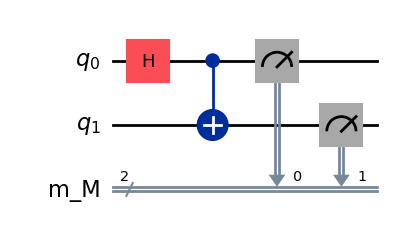

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

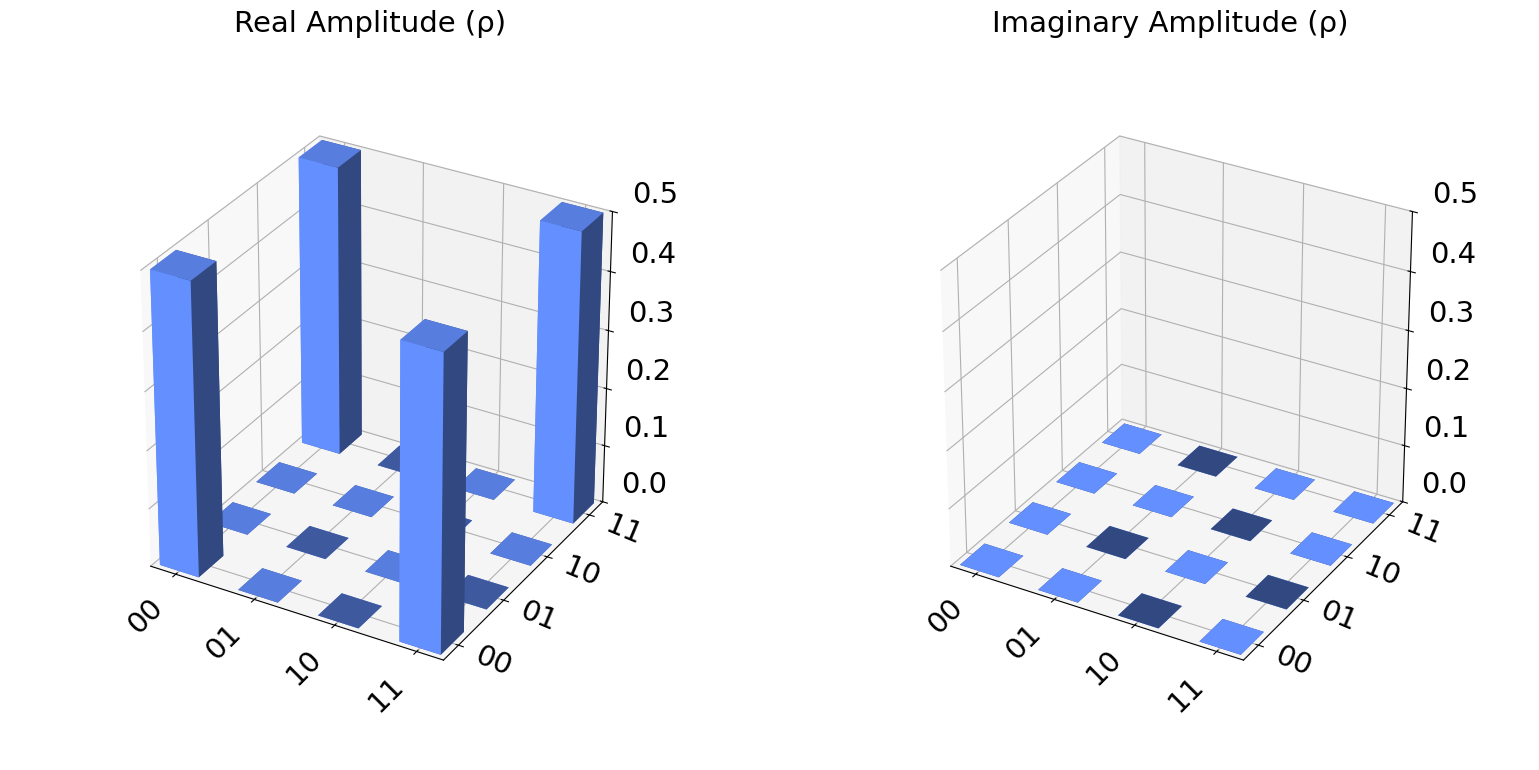

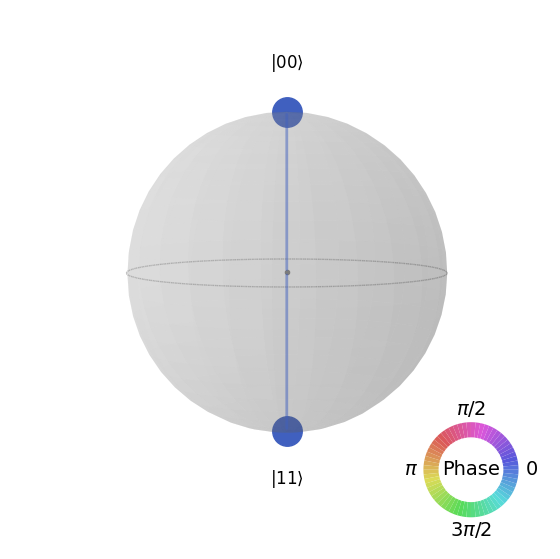

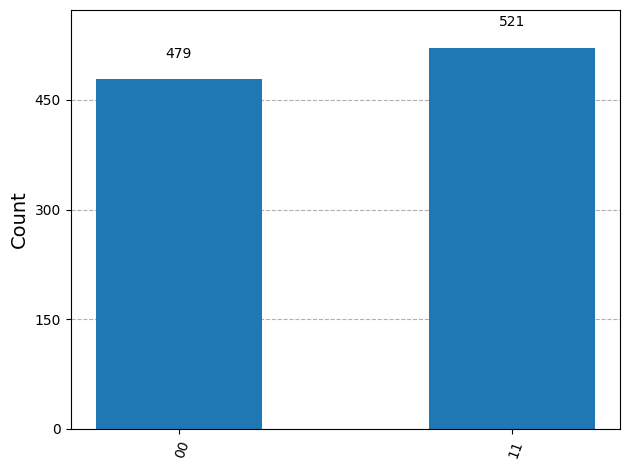

In [3]:
# --- Visualisation via Qiskit ---
# Cirq builds and runs the circuit; Qiskit is used only to render the rich views.
from qiskit.quantum_info import Statevector, DensityMatrix
from qiskit.visualization import plot_histogram
from IPython.display import display
import qiskit.qasm2

# Load the Cirq circuit's QASM into Qiskit (used for both the drawing and the statevector)
qc_pic = qiskit.qasm2.loads(bell_state.to_qasm())

# Build the statevector from the circuit (float64) so the LaTeX shows clean values
# (sqrt2/2, 1/2). Cirq's final_state_vector is float32, which renders as ugly decimals.
qc_state = qc_pic.remove_final_measurements(inplace=False)   # statevector needs no measurement
psi = Statevector(qc_state)

display(qc_pic.draw("mpl"))                # circuit diagram
display(psi.draw("latex"))                 # state vector as a ket
display(DensityMatrix(psi).draw("latex"))  # density matrix
display(psi.draw("city"))                  # state-city plot
display(psi.draw("qsphere"))               # Q-sphere
display(plot_histogram(labelled))          # measurement counts (from the Cirq run)
